In [68]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Load the saved model, data
data = pd.read_csv("data_with_probs.csv")

In [60]:
def sample_play(df, completion = 0, route_type = None, route_group = None):
    possible_plays = df[df['complete'] == completion].copy()

    if route_type is not None:
        possible_plays = possible_plays[possible_plays['route_type'] == route_type]

    if route_group is not None:
        possible_plays = possible_plays[possible_plays['route_group'] == route_group]

    plays = possible_plays[['game_id', 'play_id']].drop_duplicates()

    if len(plays) == 0:
        print("ERROR: No plays exist...")
        return None, None  # no matching play

    # Randomly sample one play
    sampled_play = plays.sample(n=1, random_state=None).iloc[0]

    return sampled_play['game_id'], sampled_play['play_id']

In [61]:
def plot_predicted_catch_prob(df, game_id, play_id):
    play_data = df[(df['game_id'] == game_id) &
                   (df['play_id'] == play_id) &
                   (df['to_release'] == 'after')
    ].copy()

    play_data = play_data.sort_values('frame_global', ascending = True)

    baseline_prob = play_data['completion_prob'].iloc[0]

    # Positive and negative area
    total_area = play_data['auc_slice'].sum()
    positive_area = play_data['auc_slice'].clip(lower=0).sum()
    negative_area = play_data['auc_slice'].clip(upper=0).sum()  # negative values

    print(f"Baseline (first frame) probability: {baseline_prob:.3f}")
    print(f"Positive area above baseline: {positive_area:.3f}")
    print(f"Negative area below baseline: {negative_area:.3f}")
    print(f"Cumulative area: {total_area:.3f}")

    # Plot probability over frames
    plt.figure(figsize=(10,5))
    plt.plot(play_data['frame_id'], play_data['completion_prob'], marker='o')
    plt.axhline(y=baseline_prob, color='red', linestyle='--', label='Baseline Probability')
    plt.xlabel('Frame ID')
    plt.ylabel('Predicted Completion Probability')
    plt.title(f'Predicted Catch Probability Over Frames\nGame {game_id}, Play {play_id}')
    plt.grid(True)
    plt.show()

Game ID: 2023121007 Play ID: 3240
Baseline (first frame) probability: 0.313
Positive area above baseline: 0.250
Negative area below baseline: 0.000
Cumulative area: 0.250


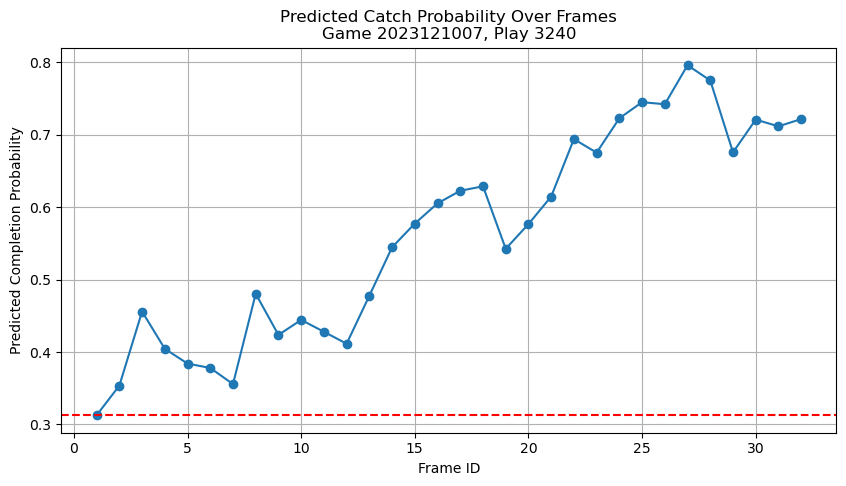

In [63]:
game_id, play_id = sample_play(data, completion = 1, route_type = None, route_group = "INTERMEDIATE")
print(f"Game ID: {game_id} Play ID: {play_id}")

plot_predicted_catch_prob(data, game_id, play_id)

In [73]:
def completion_metric_distr_plot(df):
    play_auc = df.groupby(['game_id', 'play_id']).agg({
                    'auc_slice': 'sum',
                    'complete': 'first'
                 }).reset_index()

    plt.figure(figsize=(10,6))

    # Overlay KDEs for each class
    for comp, color in zip([0, 1], ['red', 'green']):
        subset = play_auc[play_auc['complete'] == comp]
        sns.kdeplot(
            subset['auc_slice'], 
            color=color, 
            label=f"{'Complete' if comp == 1 else 'Incomplete'} ({comp})",
            fill=True,
            alpha=0.5
        )

    plt.xlabel('Sum of AUC slices per play')
    plt.ylabel('Density')
    plt.title('Distribution of cumulative completion probability gain by play outcome')
    plt.legend(title='Play Outcome')
    plt.show()

    # Optionally, inspect statistics
    print(play_auc.groupby('complete')['auc_slice'].describe())

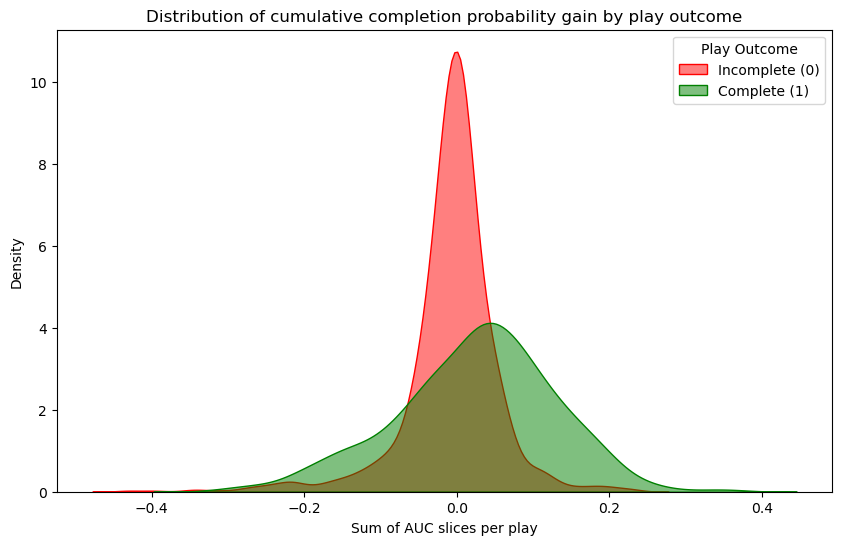

           count      mean       std       min       25%       50%       75%  \
complete                                                                       
0         1098.0 -0.007567  0.063060 -0.431569 -0.025968 -0.002265  0.018465   
1          724.0  0.024551  0.104869 -0.313723 -0.037490  0.032749  0.092779   

               max  
complete            
0         0.231308  
1         0.361743  


In [74]:
completion_metric_distr_plot(data)

In [84]:
def completion_prob_boxplot(df):
    """
    Plot distribution of average predicted completion probability per play
    (considering only frames after ball release), grouped by completion outcome.
    """
    
    # Filter frames after release
    df_after = df[df['to_release'] == 'after'].copy()
    
    # Ensure 'complete' is integer
    df_after['complete'] = df_after['complete'].astype(int)
    
    # Aggregate average completion probability per play
    play_avg = df_after.groupby(['game_id', 'play_id']).agg({
        'completion_prob': 'mean',
        'complete': 'first'
    }).reset_index()
    
    # Boxplot
    plt.figure(figsize=(8,6))
    sns.boxplot(
        data=play_avg, 
        x='complete', 
        y='completion_prob'
    )
    plt.xlabel('Complete')
    plt.ylabel('Average Predicted Completion Probability')
    plt.title('Distribution of Avg Predicted Completion Probability per Play')
    plt.show()
    
    # Optional: print descriptive stats
    print(play_avg.groupby('complete')['completion_prob'].describe())

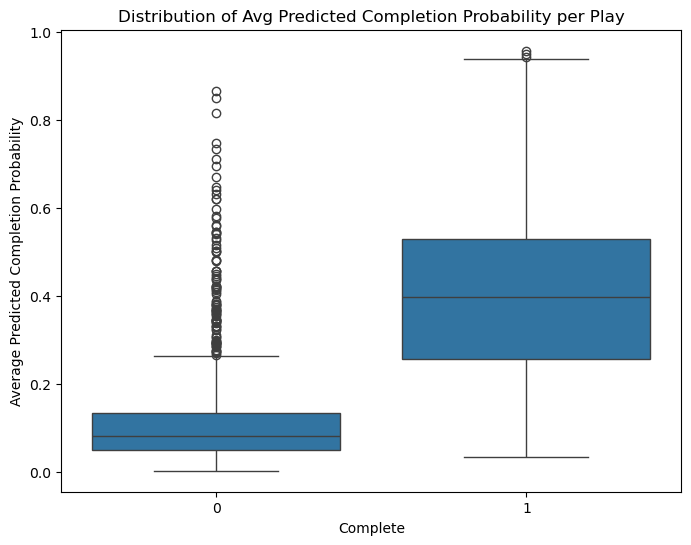

           count      mean       std       min       25%       50%       75%  \
complete                                                                       
0         1098.0  0.119371  0.119959  0.002854  0.049406  0.082146  0.134862   
1          724.0  0.424488  0.216555  0.033387  0.255618  0.397629  0.529707   

               max  
complete            
0         0.864471  
1         0.956849  


In [85]:
completion_prob_boxplot(data)

In [96]:
def rank_receivers_by_auc(df, min_plays=10):
    """
    Computes the average cumulative AUC gain per play for each targeted receiver.
    
    Parameters:
        df : DataFrame containing columns:
                ['game_id', 'play_id', 'tgt_rec_name', 'auc_slice']
        min_plays : minimum number of plays required to include a receiver in ranking.
    """
    
    # --- 1. Aggregate AUC at the play level ---
    play_level_auc = df.groupby(['game_id', 'play_id', 'tgt_rec_name']).agg({
        'auc_slice': 'sum'
    }).reset_index()

    # --- 2. Aggregate at receiver level ---
    receiver_auc = play_level_auc.groupby('tgt_rec_name').agg(
        avg_auc_per_play = ('auc_slice', 'mean'),
        total_plays = ('auc_slice', 'count')
    ).reset_index()

    # --- 3. Filter out receivers with too few plays ---
    receiver_auc = receiver_auc[receiver_auc['total_plays'] >= min_plays]

    # --- 4. Sort best → worst ---
    receiver_auc = receiver_auc.sort_values('avg_auc_per_play', ascending=False)

    return receiver_auc

In [97]:
receiver_rankings = rank_receivers_by_auc(data, min_plays=10)
receiver_rankings.head(40)

,tgt_rec_name,avg_auc_per_play,total_plays
248,Tutu Atwell,0.064505,14
109,Jahan Dotson,0.048021,10
139,Josh Palmer,0.046033,11
194,Nico Collins,0.039203,16
85,Drake London,0.036107,18
42,Chris Moore,0.035642,10
145,Justin Jefferson,0.034459,23
0,A.J. Brown,0.032751,24
231,Tank Dell,0.032497,15
23,Brandon Aiyuk,0.032371,17
